# 02 - Data Cleaning
Every cleaning operation follows **Problem -> Decision -> Reason -> Impact**. No row is silently deleted; questionable rows are *flagged* so each analysis can decide how to treat them.

The cleaning logic lives in `scripts/data_pipeline.py` (single source of truth, so the notebook and the script cannot drift apart). This notebook audits the raw data, runs the pipeline, and verifies the result.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 90)
ROOT = Path("..").resolve(); RAW = ROOT / "data" / "raw"; PROC = ROOT / "data" / "processed"

import sys; sys.path.insert(0, str(ROOT / "scripts"))
import data_pipeline as dp
raw = dp.load_raw()
o, i, p, rv, pr = raw["orders"], raw["items"], raw["payments"], raw["reviews"], raw["products"]

## 1. Missing values (raw)

In [2]:
miss = pd.concat({k: v.isna().sum()[v.isna().sum() > 0] for k, v in raw.items()}).to_frame("missing")
miss["pct_of_rows"] = [round(m / len(raw[t]) * 100, 2) for (t, _), m in miss.missing.items()]
miss

missing  pct_of_rows
orders   order_approved_at                  160         0.16
         order_delivered_carrier_date      1783         1.79
         order_delivered_customer_date     2965         2.98
reviews  review_comment_title             87656        88.34
         review_comment_message           58247        58.70
products product_category_name              610         1.85
         product_name_lenght                610         1.85
         product_description_lenght         610         1.85
         product_photos_qty                 610         1.85
         product_weight_g                     2         0.01
         product_length_cm                    2         0.01
         product_height_cm                    2         0.01
         product_width_cm                     2         0.01

**Reading it:** order date gaps line up with order status (a not-yet-delivered order has no delivery date - that is legitimate, not an error). Review comment text is optional. Product category/attribute gaps affect 610 products.

## 2. Order status vs delivery-date consistency

In [3]:
d = o.copy()
for c_ in dp.DATE_COLS: d[c_] = pd.to_datetime(d[c_])
dl = d.order_status.eq("delivered")
pd.Series({"delivered but no customer delivery date": (dl & d.order_delivered_customer_date.isna()).sum(),
 "delivered but no approval date": (dl & d.order_approved_at.isna()).sum(),
 "delivered but no carrier date": (dl & d.order_delivered_carrier_date.isna()).sum(),
 "NOT delivered but has customer delivery date": (~dl & d.order_delivered_customer_date.notna()).sum(),
 "carrier date before purchase": (d.order_delivered_carrier_date < d.order_purchase_timestamp).sum(),
 "customer delivery before carrier pickup": (d.order_delivered_customer_date < d.order_delivered_carrier_date).sum(),
 "customer delivery before purchase": (d.order_delivered_customer_date < d.order_purchase_timestamp).sum()}, name="rows").to_frame()

,rows
delivered but no customer delivery date,8
delivered but no approval date,14
delivered but no carrier date,2
NOT delivered but has customer delivery date,6
carrier date before purchase,166
customer delivery before carrier pickup,23
customer delivery before purchase,0


## 3. Outliers in price and freight

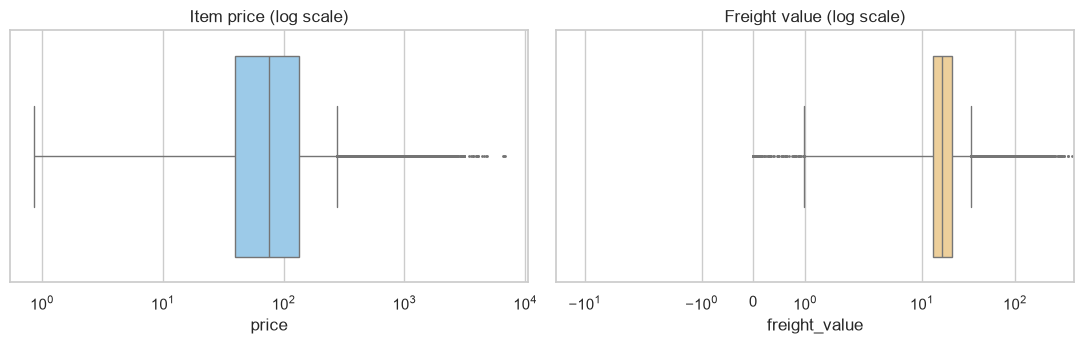

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
50%,74.99,16.26
90%,229.80,34.04
99%,890.00,84.52
max,6735.00,409.68


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sns.boxplot(x=i.price, ax=ax[0], color="#90cdf4", fliersize=1); ax[0].set_xscale("log"); ax[0].set_title("Item price (log scale)")
sns.boxplot(x=i.freight_value, ax=ax[1], color="#fbd38d", fliersize=1); ax[1].set_xscale("symlog"); ax[1].set_title("Freight value (log scale)")
plt.tight_layout(); plt.show()
i[["price","freight_value"]].describe(percentiles=[.5,.9,.99]).round(2)

**Finding:** both fields are strongly right-skewed. High values are real expensive/bulky items, not data-entry errors, so outliers are **flagged, not removed**. This also means the *median* is often a better 'typical' value than the mean.

## 4. Run the cleaning pipeline

In [5]:
tables, ri = dp.clean(raw)
log = pd.DataFrame(dp.LOG)
pd.set_option("display.max_colwidth", 200)
log[["step","problem","decision","reason","impact"]]

,step,problem,decision,reason,impact
0,orders/dates,Date columns are stored as text in the CSV,Parsed to datetime in pandas,Needed for delivery-time maths,0 rows changed; 5 columns typed
1,orders/status,"Orders with status canceled/unavailable, or with no items, are not real sales",Kept every row but flagged is_valid_sale = False; revenue KPIs use valid sales only,Avoids deleting data while stopping cancelled/unavailable orders from inflating revenue,"1,242 of 99,441 orders flagged non-sale (1.25%)"
2,orders/delivery,Delivered orders with no delivery date; canceled orders that have a delivery date,Flagged; excluded from delivery-time and late-rate metrics (delivery_metrics_ok = False). Rows kept for sales metrics,"A delivery time cannot be computed without the date, and we must not guess it",8 delivered-without-date and 6 non-delivered-with-date orders excluded from delivery metrics
3,orders/date order,Carrier pickup earlier than purchase time; customer delivery earlier than carrier pickup,Flagged only (not corrected),"Likely timestamp recording noise; delivery_days uses purchase -> customer delivery, which is not affected by the carrier timestamp","166 carrier-before-purchase, 23 customer-before-carrier rows flagged"
4,orders/period,"2016 has only 3 sparse months, and Sept/Oct 2018 have 20 orders in total (partial data)",Kept all rows; flag in_full_month_window (Jan 2017 - Aug 2018) is used for trend and growth analysis,Including tiny partial months would create fake growth/decline spikes,349 orders sit outside the trend window (0.35%)
5,customers/text,City/state text may be inconsistent,"Trimmed, city lower-cased, state upper-cased, macro-region added",Consistent grouping keys,"0 customers without region; customer_id unique=True; 96,096 real customers behind 99,441 customer_ids"
6,items/values,"Checked for price <= 0, negative freight, duplicates",No change needed,Zero invalid values found,"price<=0: 0, freight<0: 0, duplicate rows: 0; 383 items with free freight kept"
7,items/outliers,"Right-skewed prices with high values (max R$ 6,735)",Flagged with IQR rule (flag_price_outlier); NOT removed,"High prices are real luxury/bulky items, not errors; removing them would understate revenue","8,427 items (7.5%) above R$ 277"
8,payments/zero,Zero-value payments (vouchers / not_defined),Kept and flagged,Real voucher rows; harmless in sums,9 rows flagged
9,reviews/duplicates,review_id repeats and 547 orders have several reviews,Kept one review per order: the most recent by answer timestamp,"Gives one score per order, so joins do not multiply order/revenue rows","99,224 -> 98,673 rows (551 older duplicates set aside)"


## 5. Verify the cleaned data

In [6]:
fo = tables["orders"]
checks = {
 "order_id unique in cleaned orders": fo.order_id.is_unique,
 "cleaned orders row count equals raw": len(fo) == len(o),
 "one review per order": tables["reviews"].order_id.is_unique,
 "no negative delivery days": (fo.delivery_days.dropna() >= 0).all(),
 "items still all link to orders": tables["items"].order_id.isin(fo.order_id).all(),
 "raw item revenue equals cleaned item revenue": np.isclose(i.price.sum(), tables["items"].price.sum()),
 "no product without english category": (tables["products"].category_en.notna()).all()}
assert all(checks.values()), checks
pd.Series(checks, name="passed").to_frame()

,passed
order_id unique in cleaned orders,True
cleaned orders row count equals raw,True
one review per order,True
no negative delivery days,True
items still all link to orders,True
raw item revenue equals cleaned item revenue,True
no product without english category,True


In [7]:
v = fo[fo.is_valid_sale]
print(f"Valid sales orders: {len(v):,} of {len(fo):,}")
print(f"Delivered orders usable for delivery metrics: {int(fo.delivery_metrics_ok.sum()):,}")
print(f"Product value (valid sales): R$ {v.items_value.sum():,.2f} | Freight: R$ {v.freight_value.sum():,.2f}")
print(f"Late deliveries: {fo.is_late.mean()*100:.2f}% of delivery-eligible orders | Mean delivery days: {fo.delivery_days.mean():.2f}")

Valid sales orders: 98,199 of 99,441
Delivered orders usable for delivery metrics: 96,470
Product value (valid sales): R$ 13,494,400.74 | Freight: R$ 2,241,126.29
Late deliveries: 8.11% of delivery-eligible orders | Mean delivery days: 12.56


**Result:** the pipeline keeps all 99,441 orders (nothing dropped), collapses reviews to one per order, reduces geolocation to one row per zip prefix, and writes processed tables to `data/processed/` (`python scripts/data_pipeline.py`).
Full decision log: `data/processed/cleaning_log.json`.